# Customer satisfaction: Phase 1 EDA and prediction feasibility

*   Question:  Will an order receive a low review score? What review score will be received upon delivery?
*   Target: Binary (low score (1–2) versus non-low score (3–5)), ordinal (review score 1 - 5)
*   Stakeholder: Customer experience / seller quality team
*   Features:  Delivery performance, product category, freight value, customer location etc.





In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/Othercomputers/My Laptop/NUS/IT5006 Fundamentals of Data Analytics/Group Project/Project Data/smartcommerce_consolidated_v2.csv')
for column in ['review_creation_date', 'review_answer_timestamp', 'order_purchase_timestamp', 'order_delivered_customer_date']:
    df[column] = pd.to_datetime(df[column], format='mixed', errors='raise')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 45 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  object        
 1   order_item_id                  112650 non-null  int64         
 2   product_id                     112650 non-null  object        
 3   seller_id                      112650 non-null  object        
 4   shipping_limit_date            112650 non-null  object        
 5   price                          112650 non-null  float64       
 6   freight_value                  112650 non-null  float64       
 7   product_category_name_english  111023 non-null  object        
 8   product_weight_g               112632 non-null  float64       
 9   customer_id                    112650 non-null  object        
 10  order_status                   112650 non-null  object        
 11  

Check duplicates in consolidated dataset: a large proportion of order_id is duplicated.

In [ ]:
df['order_id'].duplicated().sum()

np.int64(13984)

Investigate into duplicate order_id: order_item_ids are different. Each order_id may contain one or more order items.

In [ ]:
duplicate_orders = df.loc[df['order_id'].duplicated(keep=False), 'order_id'].iloc[0]
df[df['order_id'] == duplicate_orders].T

,13,14
order_id,0008288aa423d2a3f00fcb17cd7d8719,0008288aa423d2a3f00fcb17cd7d8719
order_item_id,1,2
product_id,368c6c730842d78016ad823897a372db,368c6c730842d78016ad823897a372db
seller_id,1f50f920176fa81dab994f9023523100,1f50f920176fa81dab994f9023523100
shipping_limit_date,2018-02-21 02:55:52,2018-02-21 02:55:52
price,49.9,49.9
freight_value,13.37,13.37
product_category_name_english,garden_tools,garden_tools
product_weight_g,1650.0,1650.0
customer_id,2355af7c75e7c98b43a87b2a7f210dc5,2355af7c75e7c98b43a87b2a7f210dc5


Aggregate item prices and freight once per order. Keep missing totals missing. An all-missing category is `unknown`; partially missing categories are `incomplete-category`.

In [ ]:
def collapse_category(x):
    categories = x.dropna().unique()
    if len(categories) == 0:
        return 'unknown'
    if x.isna().any():
        return 'incomplete-category'
    return categories[0] if len(categories) == 1 else 'multi-category'

order_fields = ['customer_state', 'delivery_days', 'is_on_time', 'order_delivered_customer_date', 'order_purchase_timestamp']

df_order = df.groupby('order_id', as_index=False).agg(
    price=('price', 'sum'),
    freight_value=('freight_value', 'sum'),
    product_category_name_english=('product_category_name_english', collapse_category),
    **{col: (col, 'first') for col in order_fields}
)

# Undelivered orders have unknown punctuality, not an observed late delivery.
df_order['is_on_time'] = df_order['is_on_time'].astype('boolean')
df_order.loc[df_order.order_delivered_customer_date.isna(), 'is_on_time'] = pd.NA
df_order.head()

,order_id,price,freight_value,product_category_name_english,customer_state,delivery_days,is_on_time,order_delivered_customer_date,order_purchase_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,cool_stuff,RJ,7.0,True,2017-09-20 23:43:48,2017-09-13 08:59:02
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,pet_shop,SP,16.0,True,2017-05-12 16:04:24,2017-04-26 10:53:06
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,furniture_decor,MG,7.0,True,2018-01-22 13:19:16,2018-01-14 14:33:31
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,perfumery,SP,6.0,True,2018-08-14 13:32:39,2018-08-08 10:00:35
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,garden_tools,SP,25.0,True,2017-03-01 16:42:31,2017-02-04 13:57:51


Safety check: no duplicate order_id now

In [ ]:
df_order['order_id'].duplicated().sum()

np.int64(0)

Verify that each order has one consistent score and review timestamp before reducing repeated item-level labels to one order-level label. The consolidation's upstream review-selection rule cannot be verified from this file alone.


In [ ]:
review_fields = ['review_score', 'review_creation_date', 'review_answer_timestamp']
review_conflicts = df.groupby('order_id')[review_fields].nunique(dropna=False).gt(1)
review_conflicts.sum()

,0
review_score,0
review_creation_date,0
review_answer_timestamp,0


Merging customer review with original dataset

In [ ]:
customer_review = df[['order_id'] + review_fields].drop_duplicates('order_id')
df_with_review = df_order.merge(customer_review, on='order_id', how='left', validate='one_to_one')
df_with_review.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98666 entries, 0 to 98665
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       98666 non-null  object        
 1   price                          98666 non-null  float64       
 2   freight_value                  98666 non-null  float64       
 3   product_category_name_english  98666 non-null  object        
 4   customer_state                 98666 non-null  object        
 5   delivery_days                  96476 non-null  float64       
 6   is_on_time                     96476 non-null  boolean       
 7   order_delivered_customer_date  96476 non-null  datetime64[ns]
 8   order_purchase_timestamp       98666 non-null  datetime64[ns]
 9   review_score                   97917 non-null  float64       
 10  review_creation_date           97917 non-null  datetime64[ns]
 11  review_answer_t

Check for NA values in feature "review_score"

In [ ]:
df_with_review['review_score'].isna().sum()

np.int64(749)

Drop those NA rows, then check the distribution of review scores 1 - 5.

In [ ]:
df_sat = df_with_review.dropna(subset=['review_score']).copy()
df_sat['low_score'] = df_sat['review_score'].le(2).astype(int)
df_sat['review_score'].value_counts().sort_index()

,count
review_score,
1.0,10827
2.0,3067
3.0,8080
4.0,19012
5.0,56931


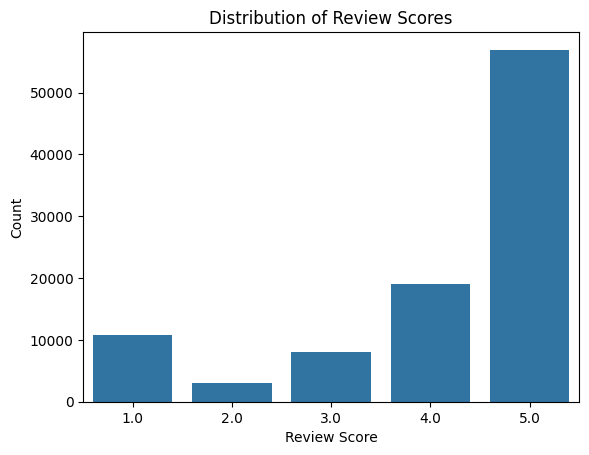

In [25]:
sns.countplot(data=df_sat, x='review_score')
plt.xlabel('Review Score')
plt.ylabel('Count')
plt.title('Distribution of Review Scores')
plt.show()

Review score by product category. Filter out categories with sample size < 30.

In [ ]:
category_stats = (df_sat.groupby('product_category_name_english')['review_score'].agg(['count', 'mean']))
category_stats_filtered = category_stats[category_stats['count'] >= 30]
category_stats_filtered.sort_values('mean')

,count,mean
product_category_name_english,,
incomplete-category,61,2.885246
multi-category,719,3.084840
office_furniture,1248,3.633013
fashion_male_clothing,110,3.727273
fashio_female_clothing,38,3.736842
...,...,...
books_imported,52,4.384615
music,36,4.388889
books_technical,253,4.418972


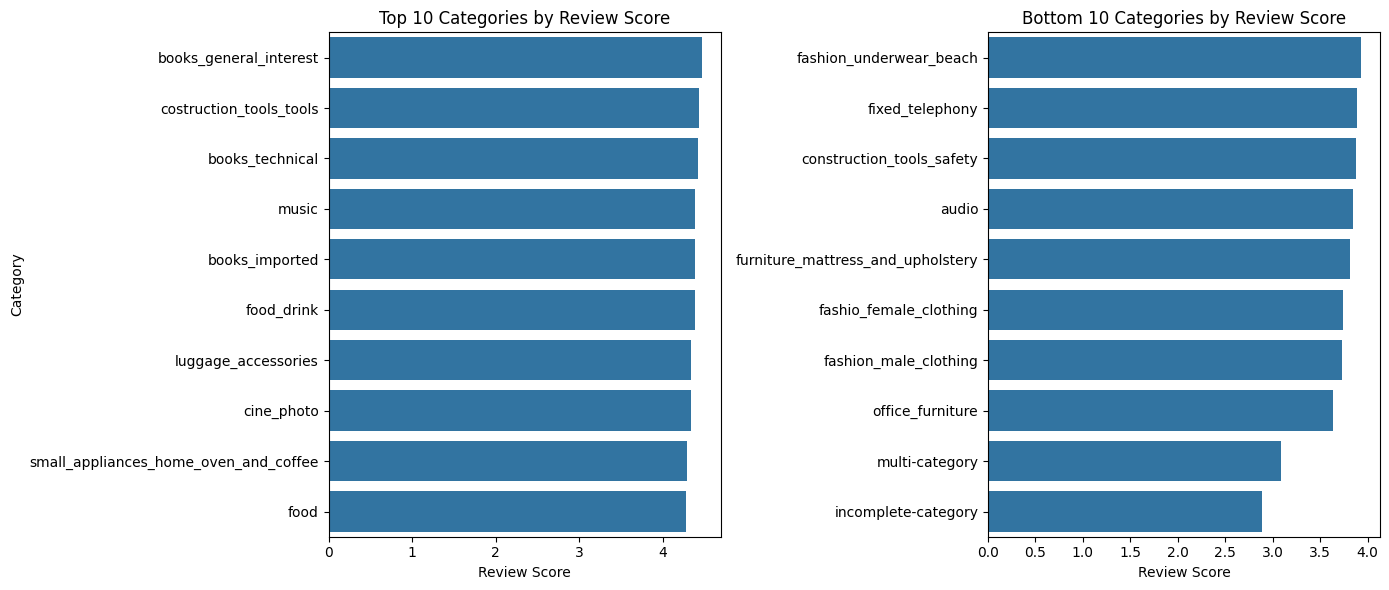

In [ ]:
top_10_categories = category_stats_filtered.sort_values('mean', ascending=False).head(10)
bottom_10_categories = category_stats_filtered.sort_values('mean', ascending=False).tail(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=top_10_categories['mean'], y=top_10_categories.index, ax=ax1)
ax1.set_title('Top 10 Categories by Review Score')
ax1.set_xlabel('Review Score')
ax1.set_ylabel('Category')

sns.barplot(x=bottom_10_categories['mean'], y=bottom_10_categories.index, ax=ax2)
ax2.set_title('Bottom 10 Categories by Review Score')
ax2.set_xlabel('Review Score')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

Use boxplot to visualize the distribution of freight value by review score. The median freight value is similar across all review scores.

<Axes: xlabel='review_score', ylabel='freight_value'>

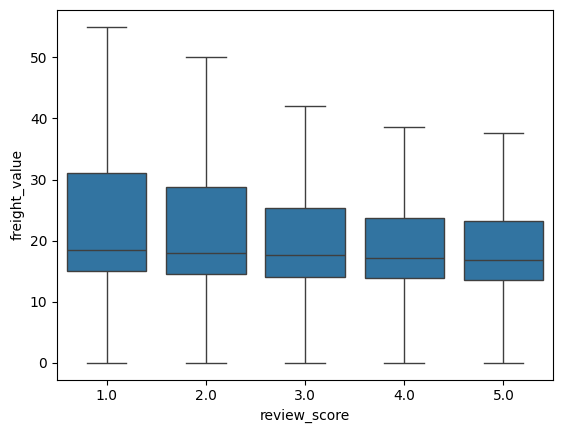

In [ ]:
sns.boxplot(
    data=df_sat,
    x='review_score',
    y='freight_value',
    showfliers=False
)

Use boxplot to visualize the distribution of freight value ratio (= freight value / price) by review score. Again, the median freight ratio is similar across all review scores.

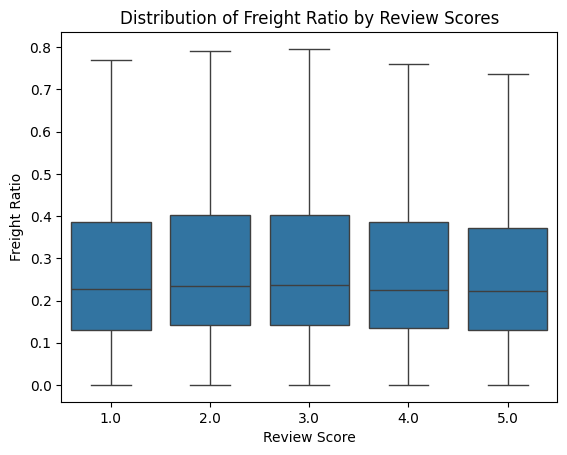

In [26]:
df_sat['freight_ratio'] = df_sat['freight_value'] / df_sat['price']
sns.boxplot(data=df_sat, x='review_score', y='freight_ratio', showfliers=False)

plt.xlabel('Review Score')
plt.ylabel('Freight Ratio')
plt.title('Distribution of Freight Ratio by Review Scores')
plt.show()


Compare review scores across freight-ratio quintiles. Mean review scores decline slightly across freight-ratio quintiles, whereas the proportion of low scores follows a modest, non-monotonic pattern.


In [ ]:
df_sat['freight_ratio_bin'] = pd.qcut(
    df_sat['freight_ratio'],
    q=5,
    duplicates='drop'
)

df_sat.groupby('freight_ratio_bin', observed=True)['review_score'].agg(
    ['count', 'mean', 'median']
)

,count,mean,median
freight_ratio_bin,,,
"(-0.001, 0.115]",19585,4.137707,5.0
"(0.115, 0.183]",19583,4.124802,5.0
"(0.183, 0.273]",19582,4.117914,5.0
"(0.273, 0.435]",19583,4.077567,5.0
"(0.435, 21.447]",19584,4.064696,5.0


Compare the low-score rate across freight-ratio quintiles. Low score proportion shows non-linear relations with freight ratio bins.

In [ ]:
df_sat['low_score'] = df_sat['review_score'] <= 2

df_sat.groupby('freight_ratio_bin', observed=True)['low_score'].mean()

,low_score
freight_ratio_bin,
"(-0.001, 0.115]",0.141486
"(0.115, 0.183]",0.137211
"(0.183, 0.273]",0.135533
"(0.273, 0.435]",0.148292
"(0.435, 21.447]",0.146957


Plot delivery duration against the observed score. Delivery time shows a  negative association with customer ratings.

<Axes: xlabel='review_score', ylabel='delivery_days'>

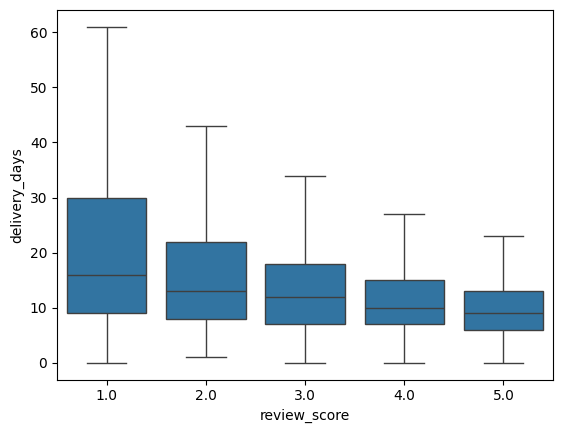

In [ ]:
sns.boxplot(
    data=df_sat,
    x='review_score',
    y='delivery_days',
    showfliers=False
)

Compare review scores across actual delivery-duration quintiles.


In [33]:
df_sat['delivery_days_bin'] = pd.qcut(
    df_sat['delivery_days'],
    q=5,
    duplicates='drop'
)

df_summary = df_sat.groupby('delivery_days_bin', observed=True)['review_score'].agg(
    ['count', 'mean', 'median']
).reset_index()
df_summary

,delivery_days_bin,count,mean,median
0,"(-0.001, 6.0]",25932,4.418209,5.0
1,"(6.0, 8.0]",14322,4.364754,5.0
2,"(8.0, 12.0]",21322,4.292327,5.0
3,"(12.0, 17.0]",16270,4.190412,5.0
4,"(17.0, 208.0]",17984,3.417093,4.0


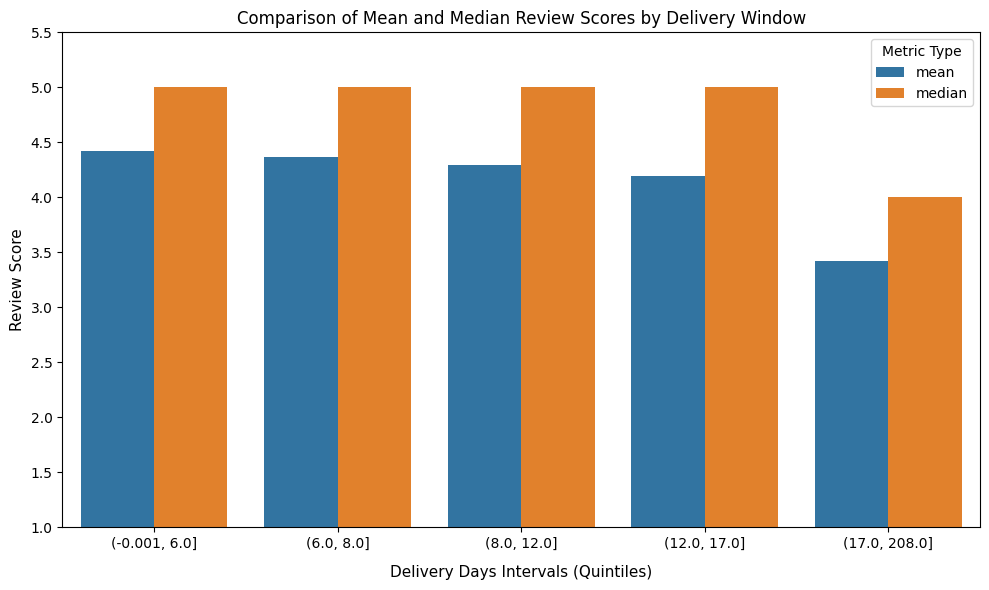

In [35]:
df_summary["delivery_days_bin"] = df_summary["delivery_days_bin"].astype(str)

df_melted = df_summary.melt(
    id_vars="delivery_days_bin",
    value_vars=["mean", "median"],
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_melted,
    x="delivery_days_bin",
    y="Score",
    hue="Metric")

plt.title(
    "Comparison of Mean and Median Review Scores by Delivery Window",
)
plt.xlabel("Delivery Days Intervals (Quintiles)", fontsize=11, labelpad=10)
plt.ylabel("Review Score", fontsize=11)
plt.ylim(1, 5.5)

plt.legend(title="Metric Type", frameon=True)
plt.tight_layout()
plt.show()

Compare review scores for observed on-time and late deliveries. Undelivered orders have missing punctuality and are excluded from these groups.


In [ ]:
df_sat.groupby('is_on_time')['review_score'].agg(['count', 'mean', 'median'])

,count,mean,median
is_on_time,,,
False,7662,2.565388,2.0
True,88168,4.293859,5.0


Compare order-level review scores by customer state, retaining sample counts.


In [ ]:
state_stats = (
    df_sat
    .groupby('customer_state')['review_score']
    .agg(['count', 'mean', 'std'])
    .sort_values('mean')
)

state_stats

,count,mean,std
customer_state,,,
RR,46,3.608696,1.556039
AL,408,3.759804,1.526555
MA,735,3.771429,1.502768
SE,344,3.837209,1.506917
PA,957,3.858934,1.462915
CE,1317,3.872437,1.457756
BA,3319,3.875264,1.432041
RJ,12598,3.893158,1.503091
PI,488,3.922131,1.435142


Construct approximate, pointwise 95% confidence intervals for mean review score. These treat orders as independent and do not adjust for repeated customers or multiple comparisons.


In [ ]:
state_stats['se'] = (
    state_stats['std'] / np.sqrt(state_stats['count'])
)
state_stats['ci_low'] = (
    state_stats['mean'] - 1.96 * state_stats['se']
)

state_stats['ci_high'] = (
    state_stats['mean'] + 1.96 * state_stats['se']
)
state_stats

,count,mean,std,se,ci_low,ci_high
customer_state,,,,,,
RR,46,3.608696,1.556039,0.229425,3.159022,4.058369
AL,408,3.759804,1.526555,0.075576,3.611675,3.907932
MA,735,3.771429,1.502768,0.055430,3.662785,3.880072
SE,344,3.837209,1.506917,0.081248,3.677964,3.996454
PA,957,3.858934,1.462915,0.047289,3.766247,3.951621
CE,1317,3.872437,1.457756,0.040169,3.793706,3.951169
BA,3319,3.875264,1.432041,0.024857,3.826544,3.923984
RJ,12598,3.893158,1.503091,0.013392,3.866910,3.919405
PI,488,3.922131,1.435142,0.064966,3.794798,4.049464


Visualize state-level means and approximate intervals. Differences are exploratory associations; interval overlap alone is not a formal test of predictor usefulness. Out-of-sample evaluation is needed to establish predictive value.


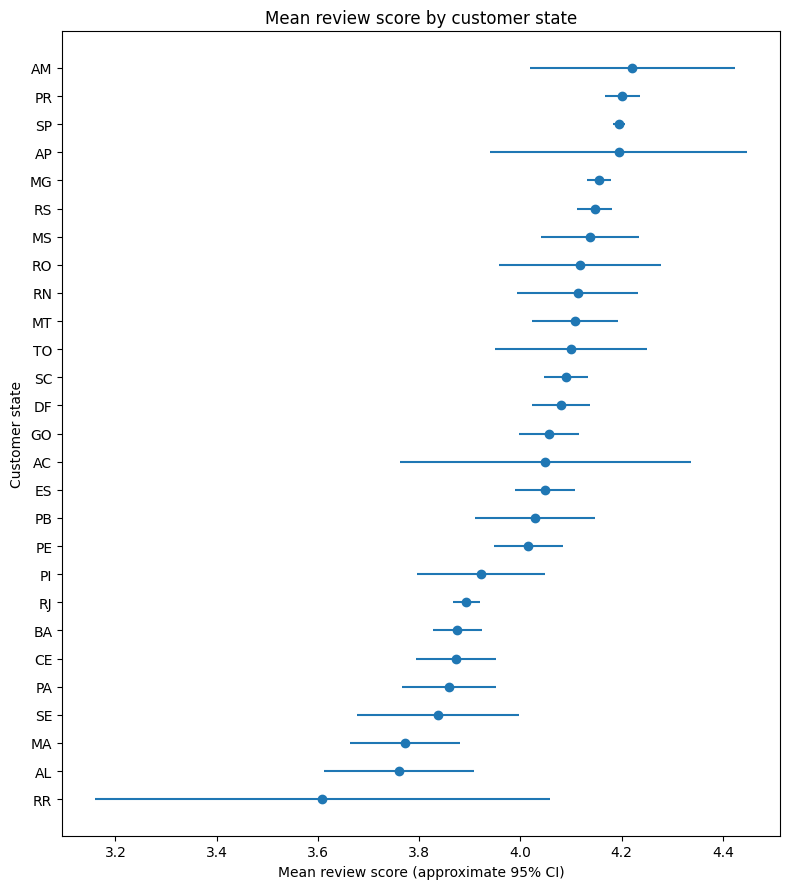

In [36]:
plt.figure(figsize=(8, 9))
plt.errorbar(x=state_stats['mean'], y=state_stats.index, xerr=1.96 * state_stats['se'], fmt='o')
plt.title('Mean review score by customer state')
plt.xlabel('Mean review score (approximate 95% CI)')
plt.ylabel('Customer state')
plt.tight_layout()
plt.show()
